# Attention visualization: three Gemma-4-31B navigation planners

This notebook compares the **attention matrices** of three trained Gemma-4-31B route
planners over a ~33-node scene graph (regions + objects). Everything is precomputed in
three small `.pt` files under `../outputs/attn_capture/` — no GPU or model weights needed.

The three models (all evaluated on the **same held-out conversation**, i.e. same graph +
same task):

1. **`llm_baseline_withedges`** — a plain LLM whose prompt contains the textual edge list.
   Task accuracy **0.95**. Sequence length `S=1450` (longer only because of the edge-list
   block), `answer_start=1231`, `P=862` node-token positions.
2. **`rpe_mask_decode_best`** — no edge text; a **learnable** graph-adjacency attention
   bias is added on the **global** attention layers at node-name token positions.
   Accuracy **0.79**. `S=714`, `answer_start=495`, `P=254`.
3. **`gmask_decode`** — same, but the bias is **parameter-free** (`0` for adjacent
   node pairs, `-inf` for non-adjacent). Accuracy **0.61**. `S=714`, `answer_start=495`,
   `P=254`.

**The question the figures answer:** does attention between node mentions follow the
graph structure, and how differently do the three models achieve it?

Layer 0 is a **sliding-window** layer (never masked); layer 5 is the **first global**
layer — this is where the graph bias applies in models 2 and 3. We therefore focus the
node-level analysis on layer 5.


In [1]:
1+1

2

In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

%matplotlib inline

ATTN_DIR = "../outputs/attn_capture"
FILES = {
    "llm_baseline_withedges": "attn_llm_baseline_withedges.pt",
    "rpe_mask_decode_best":   "attn_rpe_mask_decode_best.pt",
    "gmask_decode":           "attn_gmask_decode.pt",
}
# (display name, accuracy) for titles
DISPLAY = {
    "llm_baseline_withedges": ("LLM baseline (edge text)", 0.95),
    "rpe_mask_decode_best":   ("RPE mask (learnable bias)", 0.79),
    "gmask_decode":           ("gmask (param-free bias)", 0.61),
}
ORDER = ["llm_baseline_withedges", "rpe_mask_decode_best", "gmask_decode"]

DATA = {}
for key, fn in FILES.items():
    DATA[key] = torch.load(os.path.join(ATTN_DIR, fn), map_location="cpu", weights_only=False)

# Shared log-scale imshow helper. fp16 -> float32; zeros (causal upper triangle, masked
# entries) are masked to NaN and rendered as a light background via cmap.set_bad.
_LOG_CMAP = plt.cm.viridis.copy()
_LOG_CMAP.set_bad("#f2f2f2")

def log_imshow(ax, mat, vmin=1e-4, vmax=None, cmap=_LOG_CMAP, **kw):
    m = np.asarray(mat, dtype=np.float32)
    m = np.where(m > 0, m, np.nan)
    if vmax is None:
        vmax = np.nanmax(m) if np.isfinite(m).any() else 1.0
    im = ax.imshow(m, norm=LogNorm(vmin=vmin, vmax=vmax), cmap=cmap, **kw)
    return im

def model_title(key, extra=""):
    name, acc = DISPLAY[key]
    base = f"{name}\nacc={acc}"
    return base + (f"  |  {extra}" if extra else "")

# Quick sanity dump of what we loaded.
for key in ORDER:
    d = DATA[key]
    L0 = d["layers"][0]
    L5 = d["layers"][5]
    print(f"{key:28s} S={len(d['tokens']):4d} ans={d['answer_start']:4d} "
          f"P={len(d['node_pos']):4d} arch={d['architecture']} "
          f"edge_text={d['text_edge_list']} scope={d['injection_scope']}")
    print(          f"    layer0 is_global={L0['is_global']}  layer5 is_global={L5['is_global']}")


llm_baseline_withedges       S=1450 ans=1231 P= 862 arch=llm edge_text=present scope=full_sequence
    layer0 is_global=False  layer5 is_global=True
rpe_mask_decode_best         S= 714 ans= 495 P= 254 arch=learnable_graph_mask edge_text=none scope=decode_consistent
    layer0 is_global=False  layer5 is_global=True
gmask_decode                 S= 714 ans= 495 P= 254 arch=graph_mask_llm edge_text=none scope=decode_consistent
    layer0 is_global=False  layer5 is_global=True


## Figure 1 — Full-sequence attention overview

For each model (rows) and each of layers {0, 5} (columns), the mean-over-32-heads
attention matrix `head_mean` (`[S, S]`, rows = query token, cols = key token, **causal**
so the upper triangle is exactly 0). Log color (`LogNorm(vmin=1e-4)`); the causal zeros and
masked entries render as the light background. A line marks `answer_start` on both axes
(prompt to the left/above, generated route to the right/below).

**What to look for:** the diagonal band, how much attention mass sits on the prompt vs.
the generated route, and (for layer 5) whether structure appears at node-token positions.


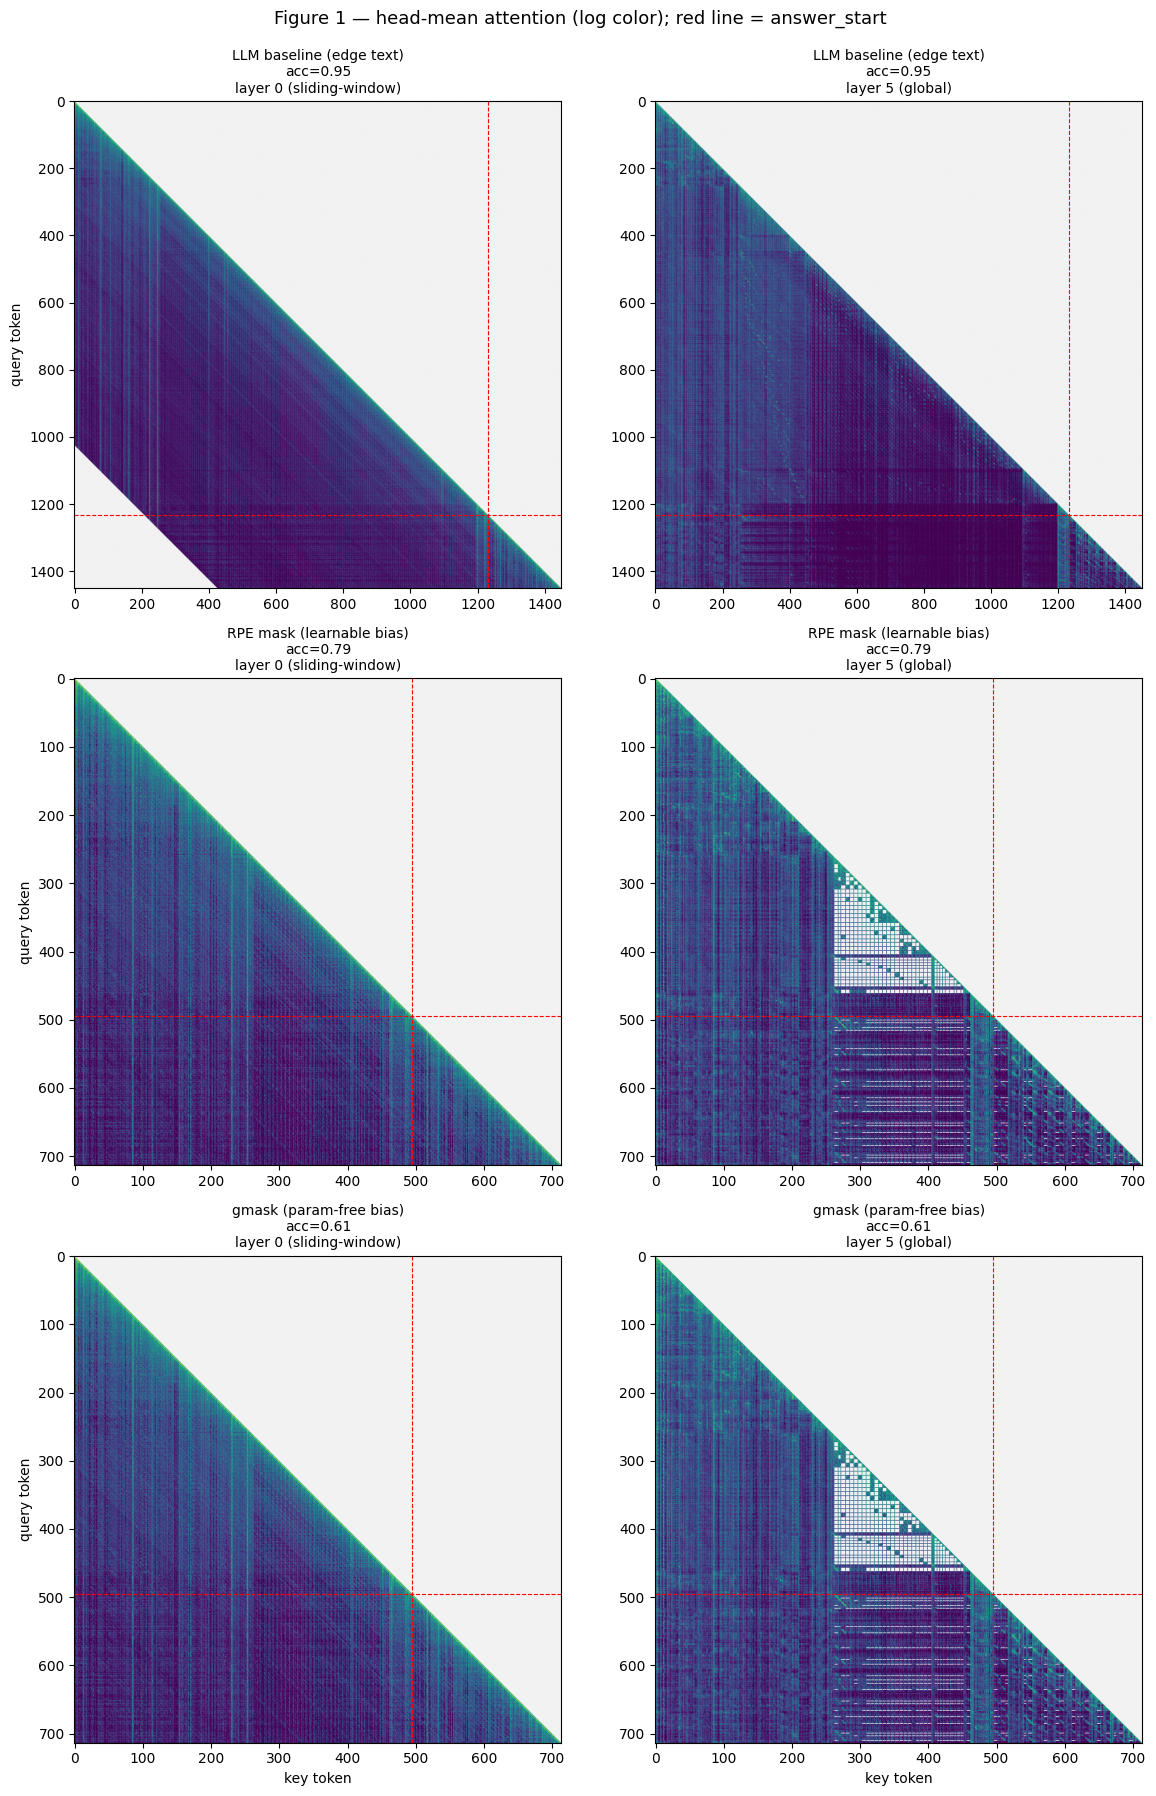

In [3]:
LAYERS = [0, 5]
fig, axes = plt.subplots(len(ORDER), len(LAYERS), figsize=(12, 18))
for r, key in enumerate(ORDER):
    d = DATA[key]
    for c, lid in enumerate(LAYERS):
        ax = axes[r, c]
        L = d["layers"][lid]
        hm = L["head_mean"].float().numpy()
        log_imshow(ax, hm)
        as_ = d["answer_start"]
        ax.axvline(as_, color="red", lw=0.8, ls="--")
        ax.axhline(as_, color="red", lw=0.8, ls="--")
        scope = "global" if L["is_global"] else "sliding-window"
        ax.set_title(f"{model_title(key)}\nlayer {lid} ({scope})", fontsize=10)
        if c == 0:
            ax.set_ylabel("query token")
        if r == len(ORDER) - 1:
            ax.set_xlabel("key token")
fig.suptitle("Figure 1 — head-mean attention (log color); red line = answer_start", y=0.995, fontsize=13)
fig.tight_layout()
plt.show()


> **Note on cross-model comparability.** Absolute token positions are **not**
> comparable between the baseline (`S=1450`, `answer_start=1231`) and the two masked
> models (`S=714`, `answer_start=495`): the baseline's sequence is longer only because
> its prompt embeds the textual edge-list block. Compare the *patterns*, not the axis
> numbers. The node-aligned view (Figure 2) puts the three models on a comparable footing.


## Figure 2 — Node-aligned comparison (layer 5)

The key figure. For layer 5, per model: mean over the 32 heads of `node_sub_per_head` →
`[P, P]` attention restricted to the `P` node-name token positions (log color). Axes are
**node tokens**, so the three models are on the same conceptual footing despite different
`P` (862 vs 254).

Sparse axis labels: for each of the 33 nodes we locate its **first** token position within
the submatrix (using `tok2node[node_pos]`) and place the node-name tick there. A red line
marks where **answer-side** node tokens begin (the first `node_pos` index `>= answer_start`)
— to the right/below that line, the rows/cols are node mentions *inside the generated route*.

**What to look for:** do bright off-diagonal entries cluster at structurally related nodes?
For the masked models the bias is applied exactly here at layer 5; for the baseline this
view omits the edge-list text entirely (see note in Figure 3).


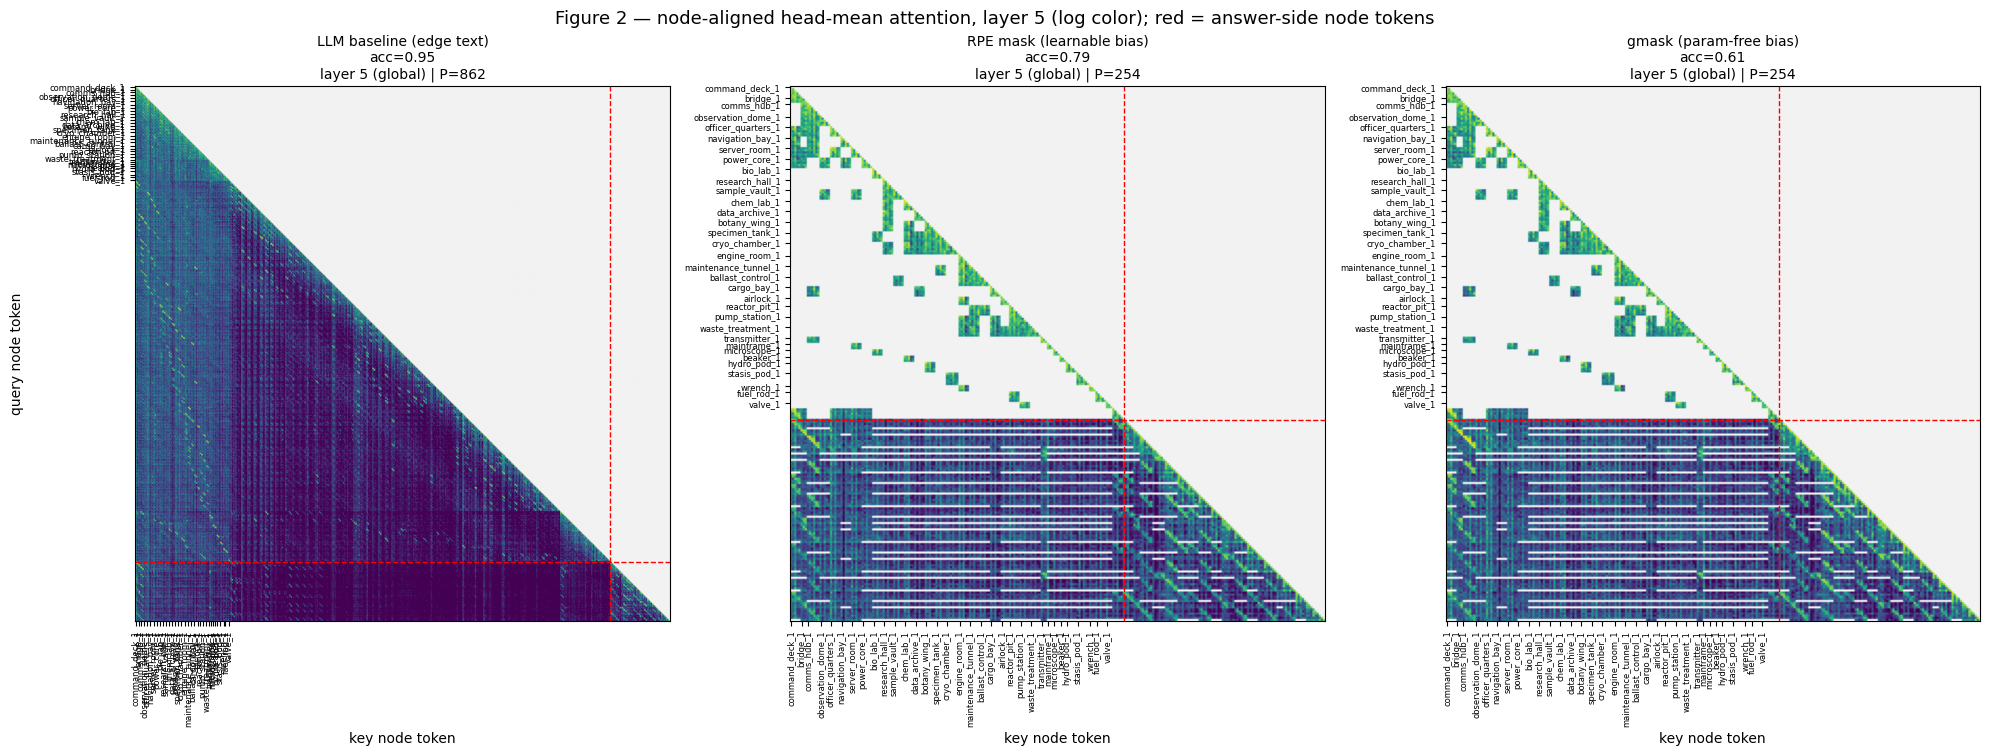

In [4]:
def node_axis_ticks(d):
    """Return (positions, labels) for each node's first token within the node submatrix."""
    node_pos = np.asarray(d["node_pos"])
    tok2node = np.asarray(d["tok2node"])
    sub_ids = tok2node[node_pos]            # node id per submatrix index
    ticks, labels = [], []
    for nid in range(len(d["node_names"])):
        idx = np.where(sub_ids == nid)[0]
        if len(idx):
            ticks.append(idx[0])
            labels.append(d["node_names"][nid])
    return np.array(ticks), labels

def answer_side_subindex(d):
    """First submatrix index whose sequence position is >= answer_start."""
    node_pos = np.asarray(d["node_pos"])
    hits = np.where(node_pos >= d["answer_start"])[0]
    return int(hits[0]) if len(hits) else len(node_pos)

fig, axes = plt.subplots(1, len(ORDER), figsize=(20, 7))
for c, key in enumerate(ORDER):
    ax = axes[c]
    d = DATA[key]
    L = d["layers"][5]
    sub = L["node_sub_per_head"].float().mean(0).numpy()   # [P, P]
    log_imshow(ax, sub)
    ticks, labels = node_axis_ticks(d)
    ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=6)
    a_idx = answer_side_subindex(d)
    ax.axvline(a_idx, color="red", lw=1.0, ls="--")
    ax.axhline(a_idx, color="red", lw=1.0, ls="--")
    ax.set_title(f"{model_title(key)}\nlayer 5 (global) | P={sub.shape[0]}", fontsize=10)
    if c == 0:
        ax.set_ylabel("query node token")
    ax.set_xlabel("key node token")
fig.suptitle("Figure 2 — node-aligned head-mean attention, layer 5 (log color); red = answer-side node tokens", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


## Figure 3 — Attention vs graph adjacency (layer 5)

We build the boolean node-adjacency matrix `A` `[33, 33]` from `edge_index` (treated as
**undirected**; self-loops `A[i,i]=1` are included so a node is "adjacent" to itself).

We then reduce the layer-5 node submatrix to a `[33, 33]` **node-level** matrix `M`:
for each `(node_i, node_j)`, take the mean attention over all `(query-token, key-token)`
pairs belonging to that pair, averaging over heads first. Per the design question — *"when
generating the route, which nodes does each mentioned node attend to?"* — we restrict
**query** tokens to the **answer side** (`position >= answer_start`, i.e. the generated
route), while **key** tokens are all node tokens (prompt descriptions + earlier route
mentions). So row `i` = a node mentioned in the route, col `j` = how much it attends to
node `j`'s tokens.

For each model we plot `M` (log color) side by side with `A` (binary), and a boxplot of
node-pair attention split by **adjacent vs non-adjacent** (off-diagonal pairs only, `i != j`,
to keep the split about *between-node* structure rather than self-attention).

**Expected (stated, then let the data speak):** the masked models should concentrate
layer-5 attention on **adjacent** node pairs; the baseline should instead route attention
through the **edge-list text** — which is invisible in this node-only projection (the
edge-list tokens are not node-name tokens, so they do not appear in `node_sub_per_head`).
That is exactly why the baseline's node-level matrix can look comparatively diffuse here
while still achieving the highest accuracy: its "graph reasoning" lives in the edge-list
text tokens, not in node-to-node attention.


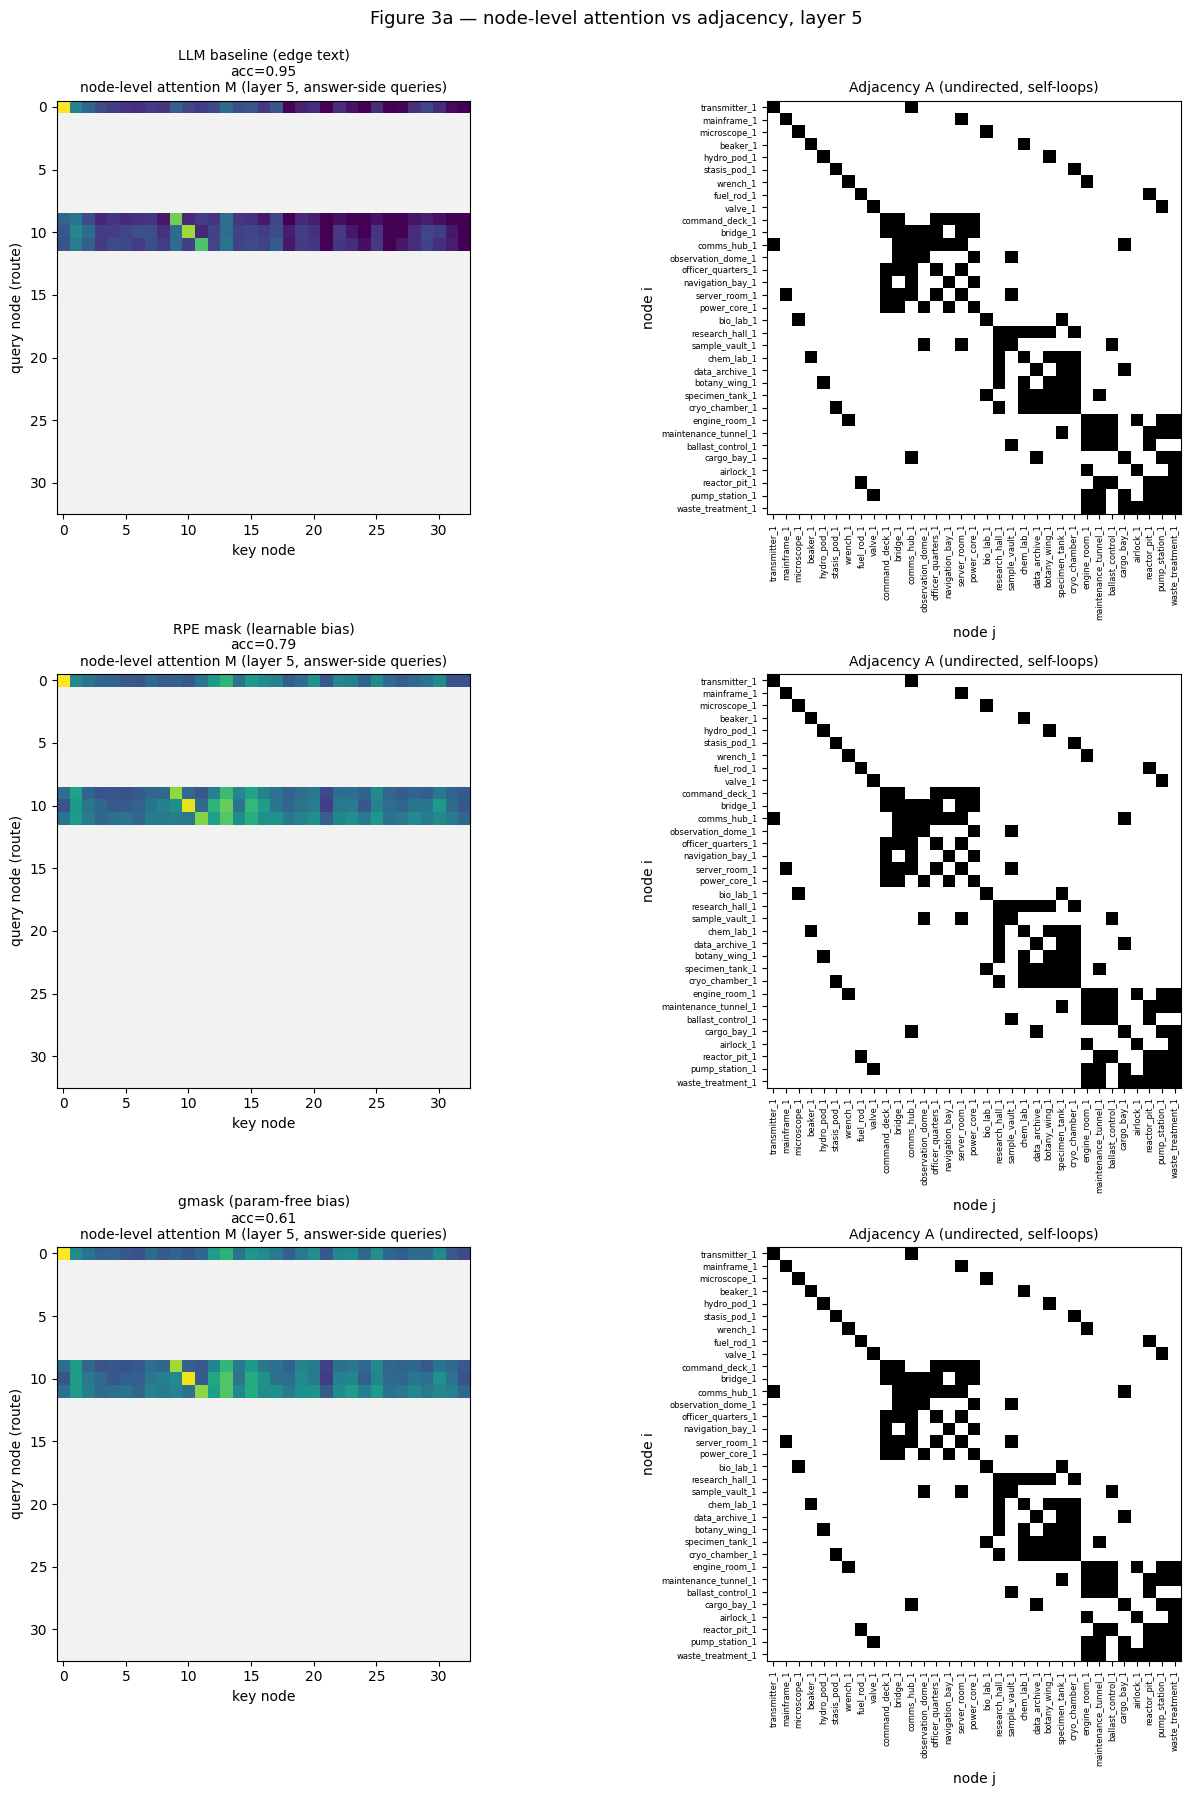

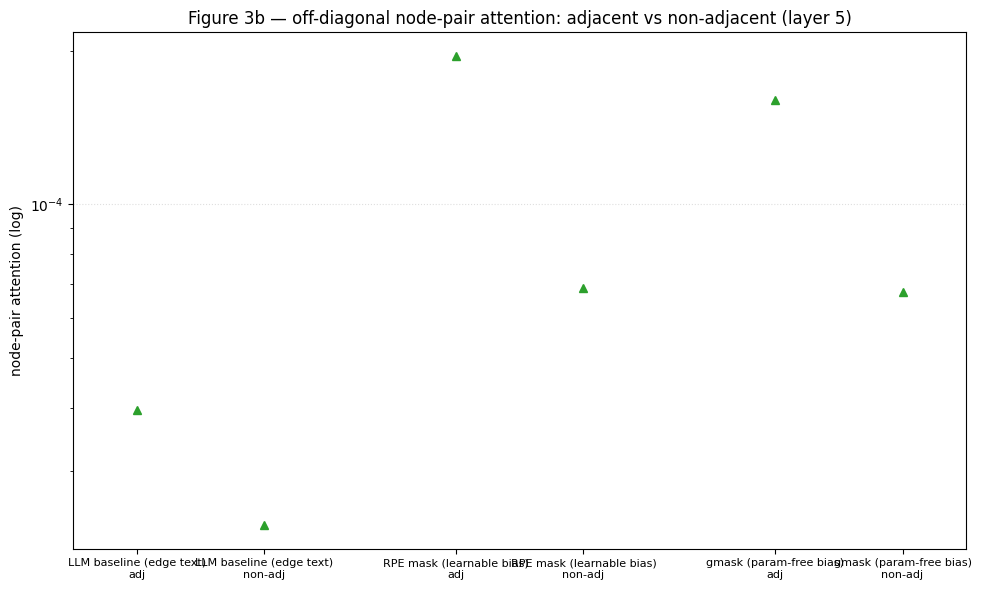

In [5]:
def build_adjacency(d):
    n = len(d["node_names"])
    A = np.eye(n, dtype=bool)  # self-loops
    src, dst = d["edge_index"]
    for s, t in zip(src, dst):
        s, t = int(s), int(t)
        A[s, t] = True
        A[t, s] = True
    return A

def node_level_matrix(d, lid=5):
    """[33,33] mean attention, queries restricted to answer-side node tokens."""
    n = len(d["node_names"])
    L = d["layers"][lid]
    sub = L["node_sub_per_head"].float().mean(0).numpy()      # [P, P]
    node_pos = np.asarray(d["node_pos"])
    tok2node = np.asarray(d["tok2node"])
    sub_ids = tok2node[node_pos]                               # node id per submatrix index
    a_idx = answer_side_subindex(d)
    q_answer = np.arange(sub.shape[0]) >= a_idx                # answer-side query rows
    M = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        qrows = np.where(q_answer & (sub_ids == i))[0]
        if len(qrows) == 0:
            continue
        for j in range(n):
            kcols = np.where(sub_ids == j)[0]
            if len(kcols) == 0:
                continue
            M[i, j] = sub[np.ix_(qrows, kcols)].mean()
    return M

A = build_adjacency(DATA["rpe_mask_decode_best"])  # identical graph across models
M = {key: node_level_matrix(DATA[key], lid=5) for key in ORDER}

# 3x2 grid: col0 = node-level attention M (log), col1 = adjacency A (binary)
fig, axes = plt.subplots(len(ORDER), 2, figsize=(14, 18))
for r, key in enumerate(ORDER):
    axM, axA = axes[r, 0], axes[r, 1]
    log_imshow(axM, M[key])
    axM.set_title(f"{model_title(key)}\nnode-level attention M (layer 5, answer-side queries)", fontsize=10)
    axM.set_xlabel("key node"); axM.set_ylabel("query node (route)")

    axA.imshow(A.astype(float), cmap="Greys", vmin=0, vmax=1)
    axA.set_title("Adjacency A (undirected, self-loops)", fontsize=10)
    axA.set_xlabel("node j"); axA.set_ylabel("node i")
    nn = DATA[key]["node_names"]
    axA.set_xticks(range(len(nn))); axA.set_xticklabels(nn, rotation=90, fontsize=6)
    axA.set_yticks(range(len(nn))); axA.set_yticklabels(nn, fontsize=6)
fig.suptitle("Figure 3a — node-level attention vs adjacency, layer 5", y=0.995, fontsize=13)
fig.tight_layout()
plt.show()

# Boxplot: off-diagonal node-pair attention, adjacent vs non-adjacent, per model.
fig, ax = plt.subplots(figsize=(10, 6))
positions, box_data, labels = [], [], []
x = 0
for key in ORDER:
    m = M[key]
    off = ~np.eye(len(m), dtype=bool)
    adj = A & off
    nonadj = (~A) & off
    vals_adj = m[adj]
    vals_non = m[nonadj]
    box_data += [vals_adj, vals_non]
    positions += [x, x + 1]
    labels += [f"{DISPLAY[key][0]}\nadj", f"{DISPLAY[key][0]}\nnon-adj"]
    x += 2.5
bp = ax.boxplot(box_data, positions=positions, widths=0.8, showfliers=False, showmeans=True)
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("node-pair attention (log)")
ax.set_title("Figure 3b — off-diagonal node-pair attention: adjacent vs non-adjacent (layer 5)")
ax.grid(True, axis="y", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()


## Figure 4 — Per-head gallery (layer 5, model 2 only)

A `4 x 8` grid showing **each of the 32 heads**' node submatrix (`[P, P]`, log color) for
`rpe_mask_decode_best` (the learnable-bias model) at layer 5. The graph-adjacency bias is
added per-head on the global layers, so this view asks whether the mask's effect is
**uniform across heads** or whether individual heads specialize (e.g. some heads carrying
the structural bias, others doing semantic/content attention).

The red line marks where answer-side node tokens begin.


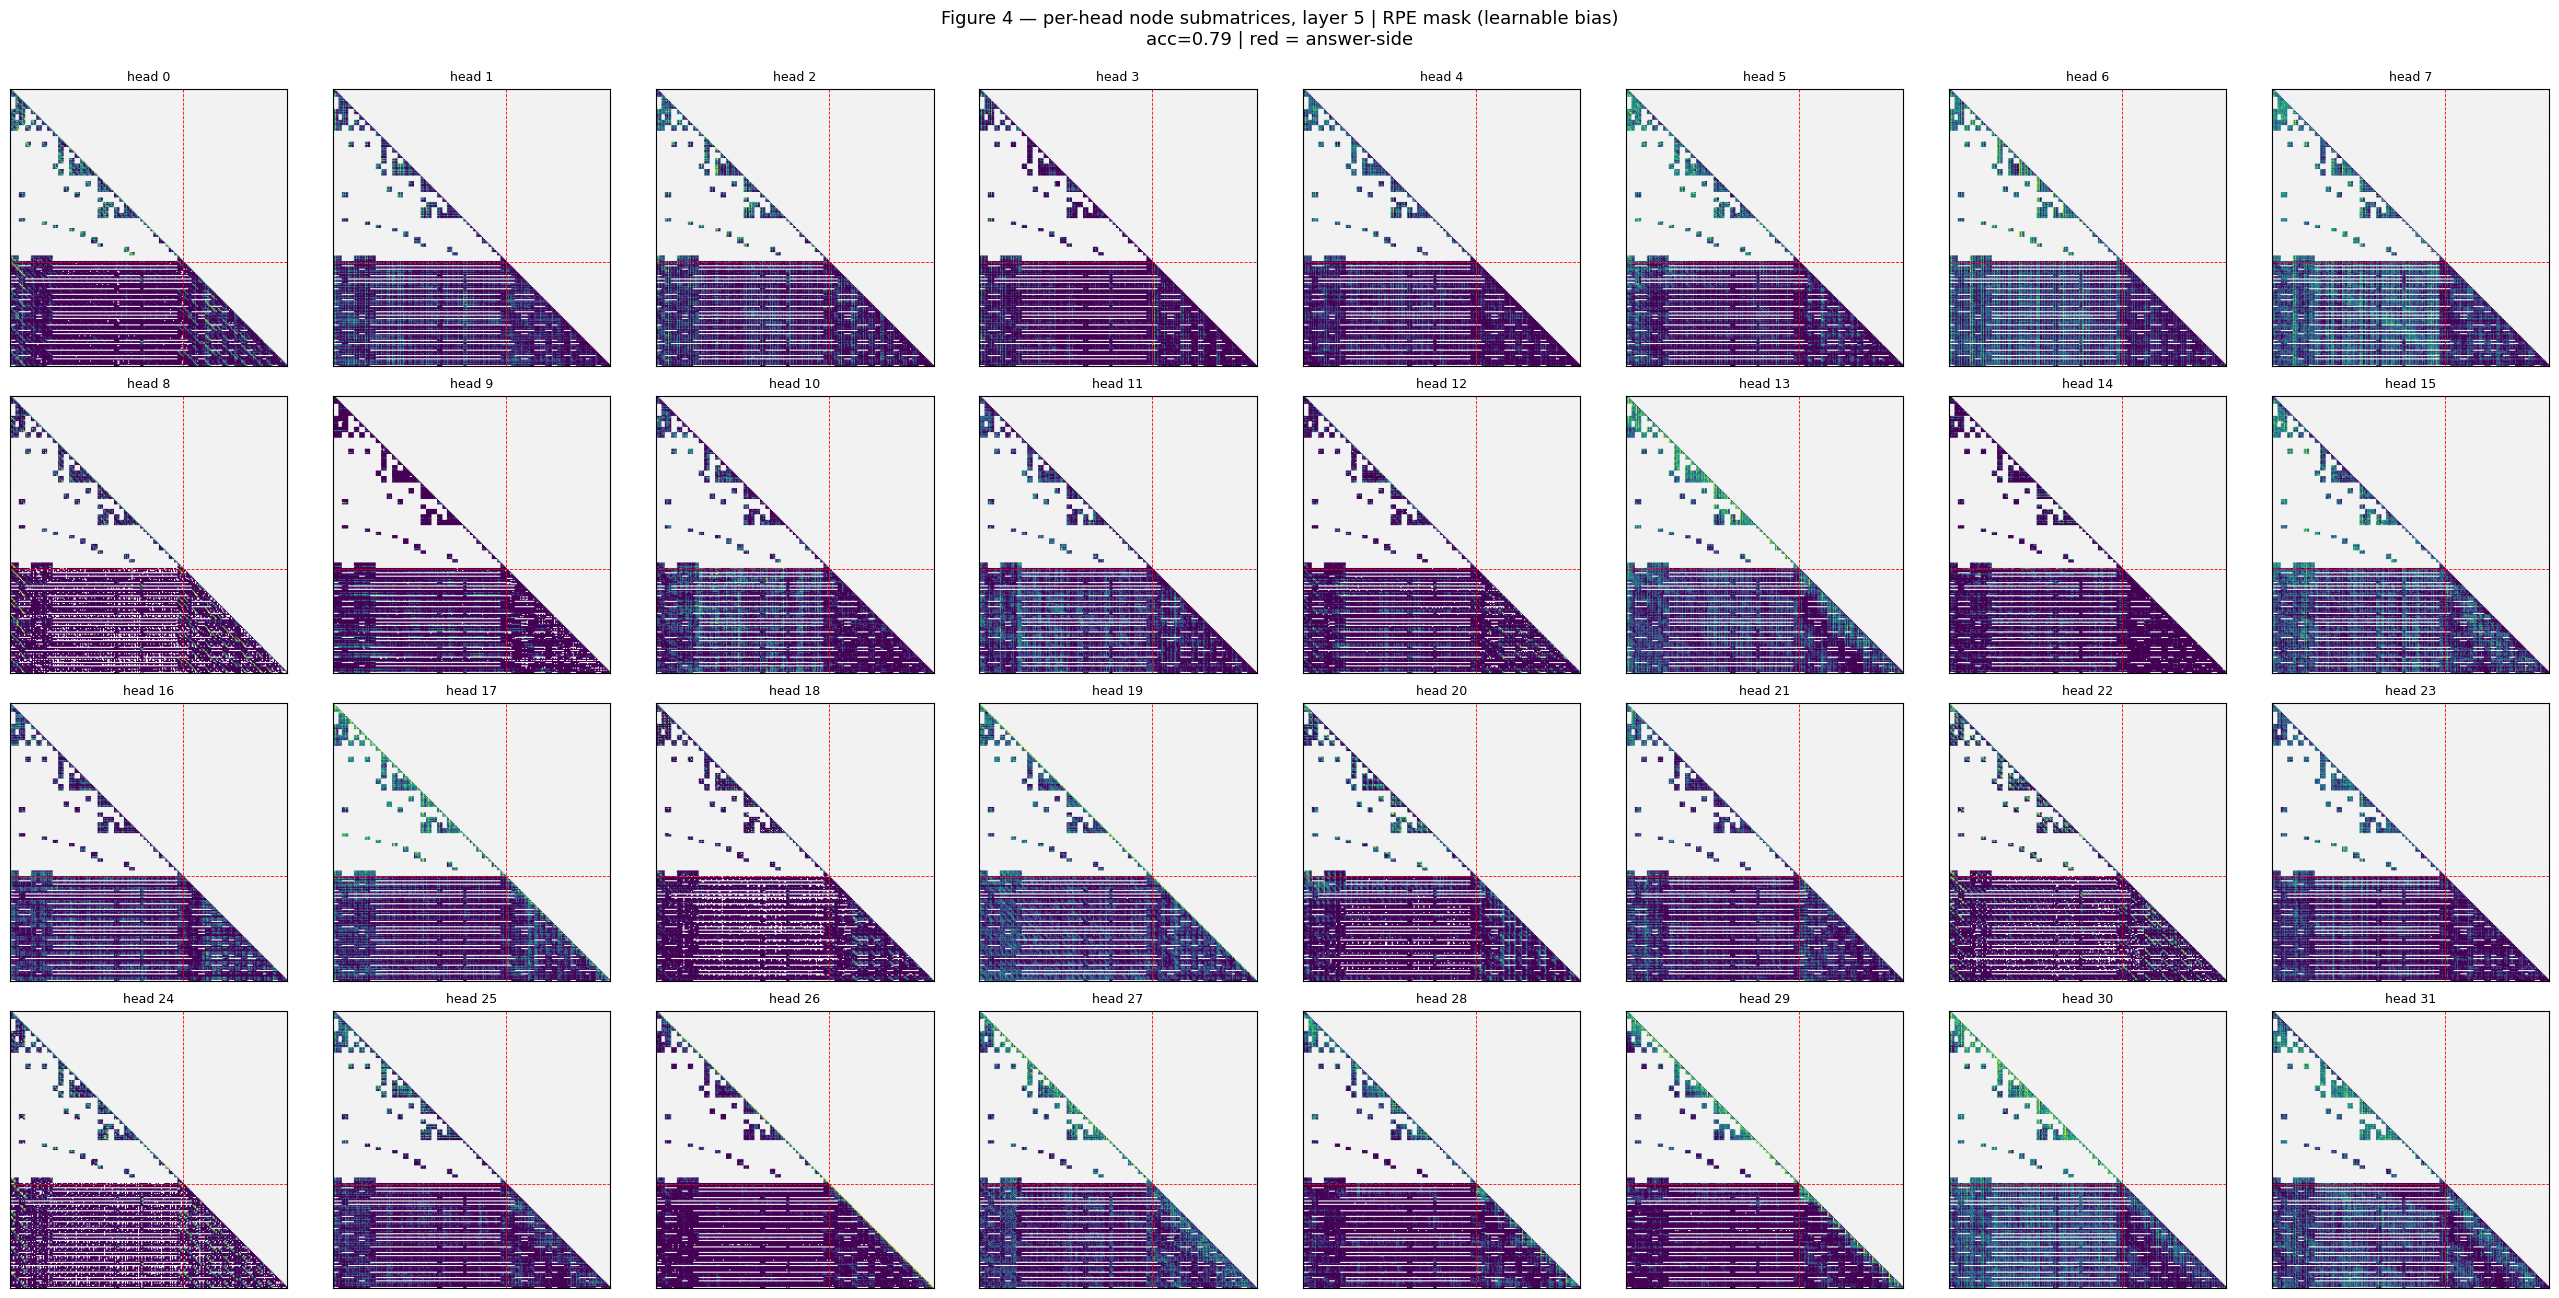

In [6]:
key = "rpe_mask_decode_best"
d = DATA[key]
L = d["layers"][5]
sub = L["node_sub_per_head"].float().numpy()          # [32, P, P]
a_idx = answer_side_subindex(d)
nH = sub.shape[0]
fig, axes = plt.subplots(4, 8, figsize=(26, 13))
for h in range(nH):
    ax = axes[h // 8, h % 8]
    log_imshow(ax, sub[h])
    ax.axvline(a_idx, color="red", lw=0.6, ls="--")
    ax.axhline(a_idx, color="red", lw=0.6, ls="--")
    ax.set_title(f"head {h}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Figure 4 — per-head node submatrices, layer 5 | {model_title(key)} | red = answer-side",
             y=0.995, fontsize=13)
fig.tight_layout()
plt.show()
